In [2]:
# Cell 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [7]:
# Cell 2: Load Data
import os

# Correct path
DB_PATH = r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\bluestock_mf.db'
RAW_PATH = r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\data\raw'
PROCESSED_PATH = r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\data\processed'

conn = sqlite3.connect(DB_PATH)

# Check tables first
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in DB:", tables['name'].tolist())

# Load all tables
nav_df = pd.read_sql("SELECT * FROM fact_nav", conn)
fund_df = pd.read_sql("SELECT * FROM dim_fund", conn)
trans_df = pd.read_sql("SELECT * FROM fact_transactions", conn)
perf_df = pd.read_sql("SELECT * FROM fact_performance", conn)
aum_df = pd.read_sql("SELECT * FROM fact_aum", conn)
conn.close()

# Load CSVs
sip_df = pd.read_csv(f'{RAW_PATH}/04_monthly_sip_inflows.csv')
cat_df = pd.read_csv(f'{RAW_PATH}/05_category_inflows.csv')
folio_df = pd.read_csv(f'{RAW_PATH}/06_industry_folio_count.csv')
portfolio_df = pd.read_csv(f'{RAW_PATH}/09_portfolio_holdings.csv')

# Date parsing
nav_df['date'] = pd.to_datetime(nav_df['date'])
trans_df['transaction_date'] = pd.to_datetime(trans_df['transaction_date'])

print(f"✅ NAV records: {len(nav_df)}")
print(f"✅ Funds: {len(fund_df)}")
print(f"✅ Transactions: {len(trans_df)}")
print("\n✅ All data loaded!")

Tables in DB: ['dim_fund', 'fact_nav', 'fact_transactions', 'fact_performance', 'fact_aum']
✅ NAV records: 46000
✅ Funds: 40
✅ Transactions: 32778

✅ All data loaded!


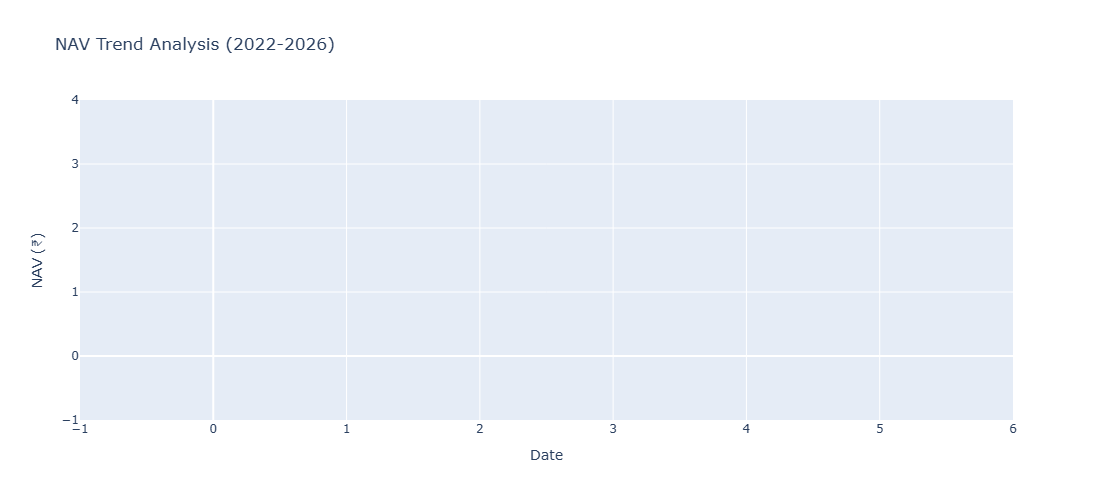

✅ Chart 1: NAV Trend done!


In [8]:
# Cell 3: NAV Trend Analysis - All 40 Schemes
nav_merged = nav_df.merge(fund_df[['amfi_code','scheme_name','fund_house']], 
                           on='amfi_code', how='left')

# Filter 2022-2026
nav_filtered = nav_merged[nav_merged['date'] >= '2022-01-01']

# Plot top 5 funds only (readable గా ఉంటుంది)
top5 = ['SBI Bluechip Fund', 'ICICI Prudential Bluechip Fund',
        'HDFC Top 100 Fund', 'Nippon India Large Cap Fund',
        'Kotak Bluechip Fund']

fig = px.line(
    nav_filtered[nav_filtered['scheme_name'].isin(top5)],
    x='date', y='nav',
    color='scheme_name',
    title='NAV Trend Analysis (2022-2026)',
    labels={'nav': 'NAV (₹)', 'date': 'Date'}
)
fig.update_layout(height=500)
fig.show()
print("✅ Chart 1: NAV Trend done!")

Available schemes:
<StringArray>
[         'HDFC Top 100 Fund - Regular Plan - Growth',
       'HDFC Short Term Debt Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
      'ABSL Frontline Equity Fund - Regular - Growth',
             'ABSL Small Cap Fund - Regular - Growth',
                'ABSL Liquid Fund - Regular - Growth',
         'UTI Nifty 50 Index Fund - Regular - Growth',
                'UTI Mid Cap Fund - Regular - Growth',
              'UTI Flexi Cap Fund - Regular - Growth',
     'Nippon India Large Cap Fund - Regular - Growth']
Length: 10, dtype: str


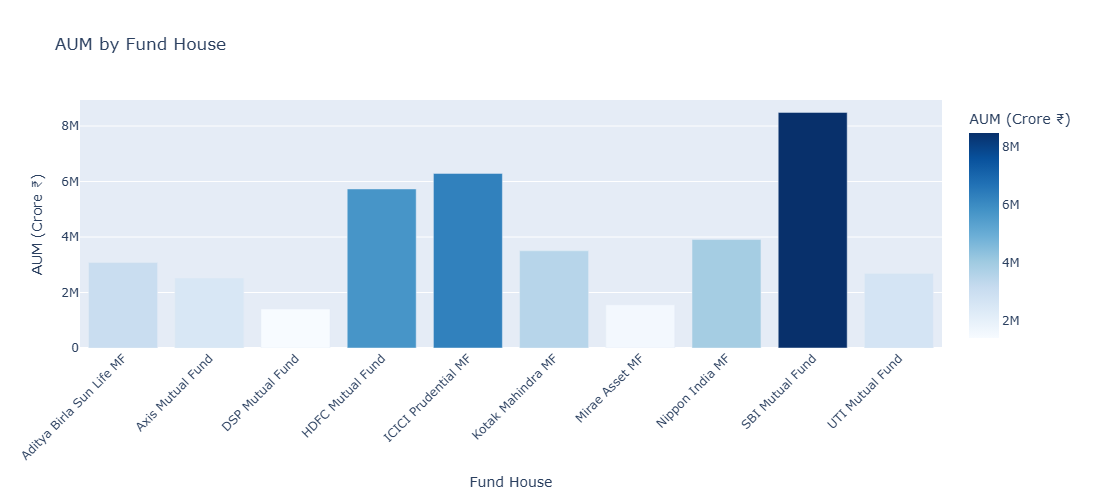

✅ Chart 2: AUM Bar Chart done!


In [9]:
# Cell 4: Check actual scheme names + AUM Chart

# First check what scheme names exist
print("Available schemes:")
print(nav_merged['scheme_name'].dropna().unique()[:10])

# AUM Growth Bar Chart
fig2 = px.bar(
    aum_df.groupby('fund_house')['aum_crore'].sum().reset_index(),
    x='fund_house', y='aum_crore',
    title='AUM by Fund House',
    labels={'aum_crore': 'AUM (Crore ₹)', 'fund_house': 'Fund House'},
    color='aum_crore',
    color_continuous_scale='Blues'
)
fig2.update_layout(xaxis_tickangle=-45, height=500)
fig2.show()
print("✅ Chart 2: AUM Bar Chart done!")

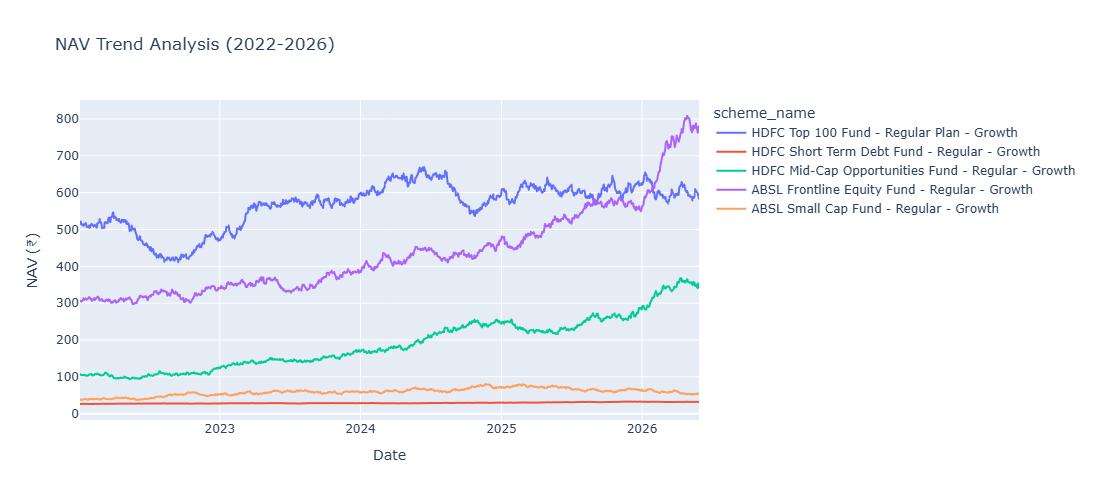

✅ Chart 1 Fixed: NAV Trend done!


In [10]:
# Cell 3 Fix: NAV Trend with correct scheme names
top5_schemes = nav_merged['scheme_name'].dropna().unique()[:5]

nav_top5 = nav_merged[
    (nav_merged['scheme_name'].isin(top5_schemes)) &
    (nav_merged['date'] >= '2022-01-01')
]

fig1 = px.line(
    nav_top5,
    x='date', y='nav',
    color='scheme_name',
    title='NAV Trend Analysis (2022-2026)',
    labels={'nav': 'NAV (₹)', 'date': 'Date'}
)
fig1.update_layout(height=500)
fig1.show()
print("✅ Chart 1 Fixed: NAV Trend done!")

In [11]:
# Cell 5: SIP Inflow Time Series
print(sip_df.columns.tolist())
print(sip_df.head())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


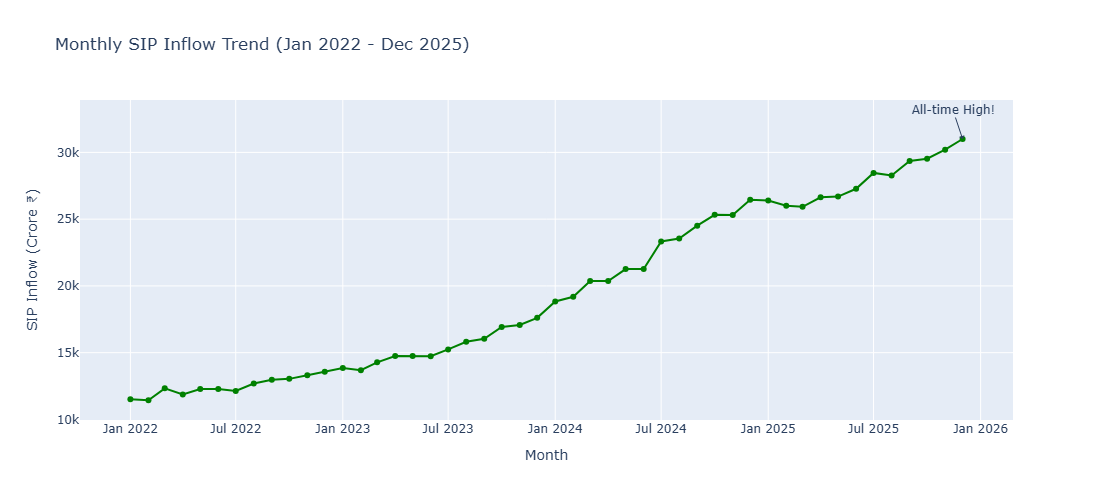

✅ Chart 3: SIP Time Series done!


In [12]:
# Cell 6: SIP Inflow Time Series
sip_df['month'] = pd.to_datetime(sip_df['month'])

fig3 = px.line(
    sip_df,
    x='month', y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
    labels={'sip_inflow_crore': 'SIP Inflow (Crore ₹)', 'month': 'Month'},
    markers=True
)
fig3.add_annotation(
    x='2025-12-01', y=sip_df['sip_inflow_crore'].max(),
    text="All-time High!",
    showarrow=True, arrowhead=1
)
fig3.update_traces(line_color='green')
fig3.update_layout(height=500)
fig3.show()
print("✅ Chart 3: SIP Time Series done!")

In [13]:
# Cell 7: Category Inflow Heatmap
print(cat_df.columns.tolist())
print(cat_df.head())

['month', 'category', 'net_inflow_crore']
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


FileNotFoundError: [Errno 2] No such file or directory: 'reports/chart4_category_heatmap.png'

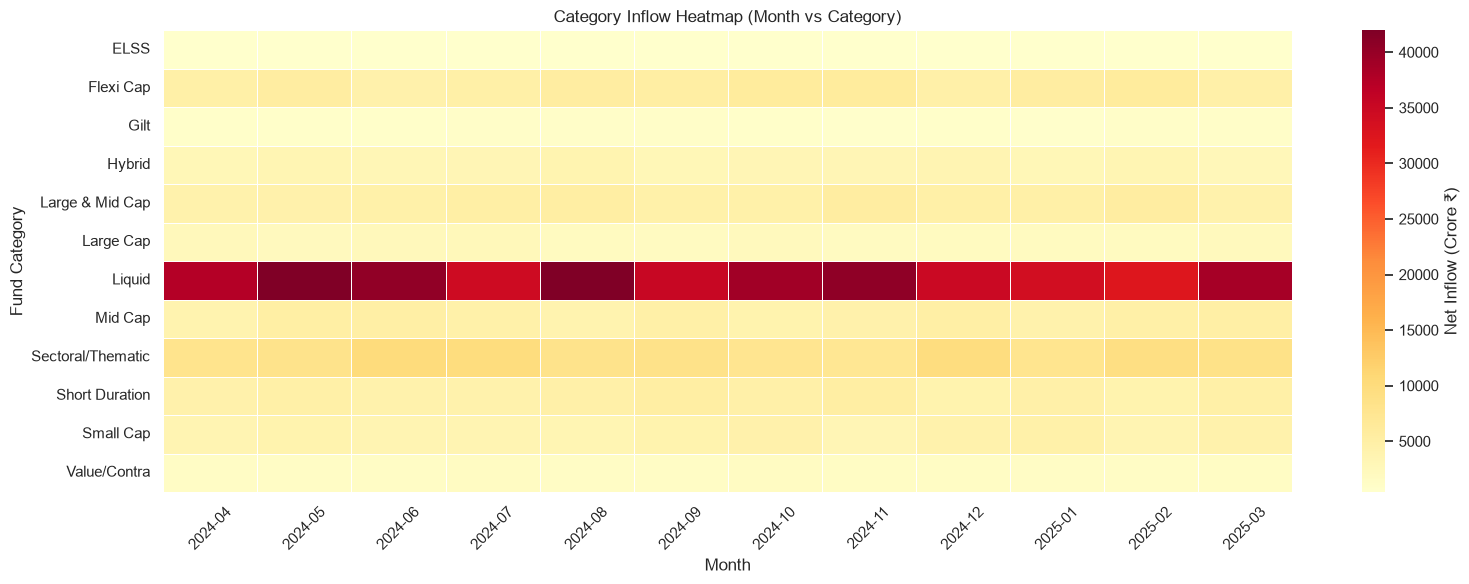

In [14]:
# Cell 8: Category Inflow Heatmap
cat_df['month'] = pd.to_datetime(cat_df['month'])
cat_pivot = cat_df.pivot_table(
    index='category', 
    columns=cat_df['month'].dt.strftime('%Y-%m'),
    values='net_inflow_crore'
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    cat_pivot,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (Crore ₹)'}
)
plt.title('Category Inflow Heatmap (Month vs Category)')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/chart4_category_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4: Category Heatmap done!")

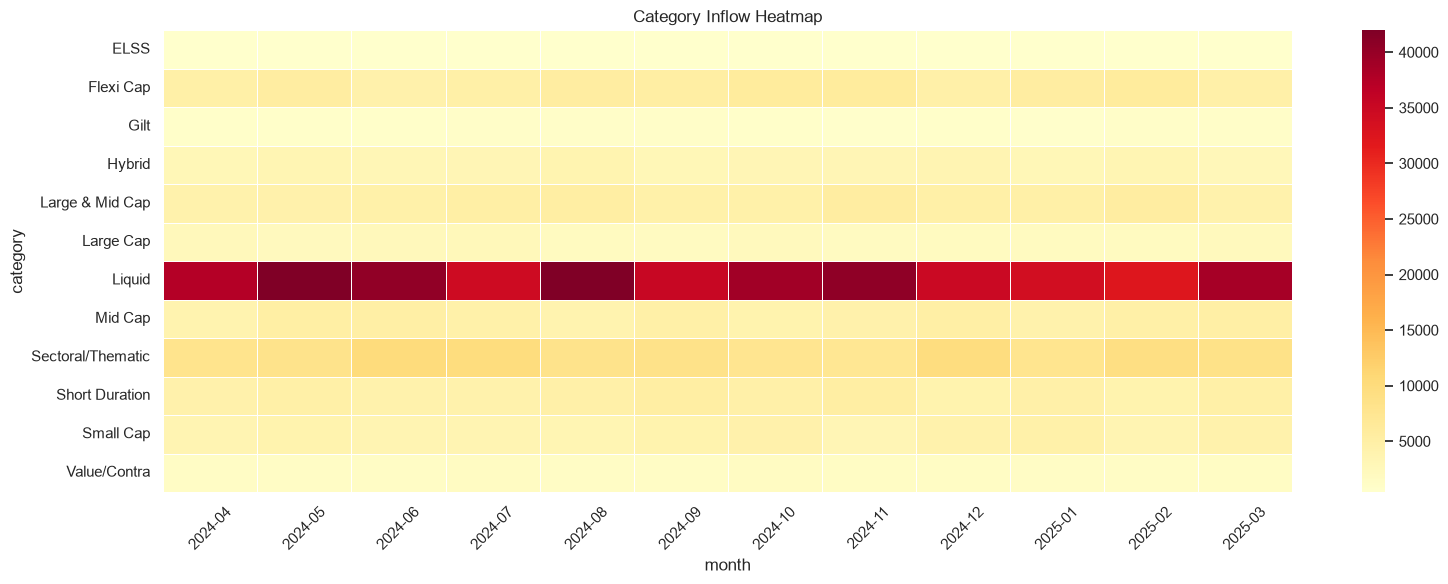

✅ Chart 4 saved!


In [15]:
# Fix: Create reports folder and save
import os
os.makedirs(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports', exist_ok=True)

plt.figure(figsize=(16, 6))
cat_pivot2 = cat_df.pivot_table(
    index='category',
    columns=cat_df['month'].dt.strftime('%Y-%m'),
    values='net_inflow_crore'
)
sns.heatmap(cat_pivot2, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title('Category Inflow Heatmap')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports\chart4_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

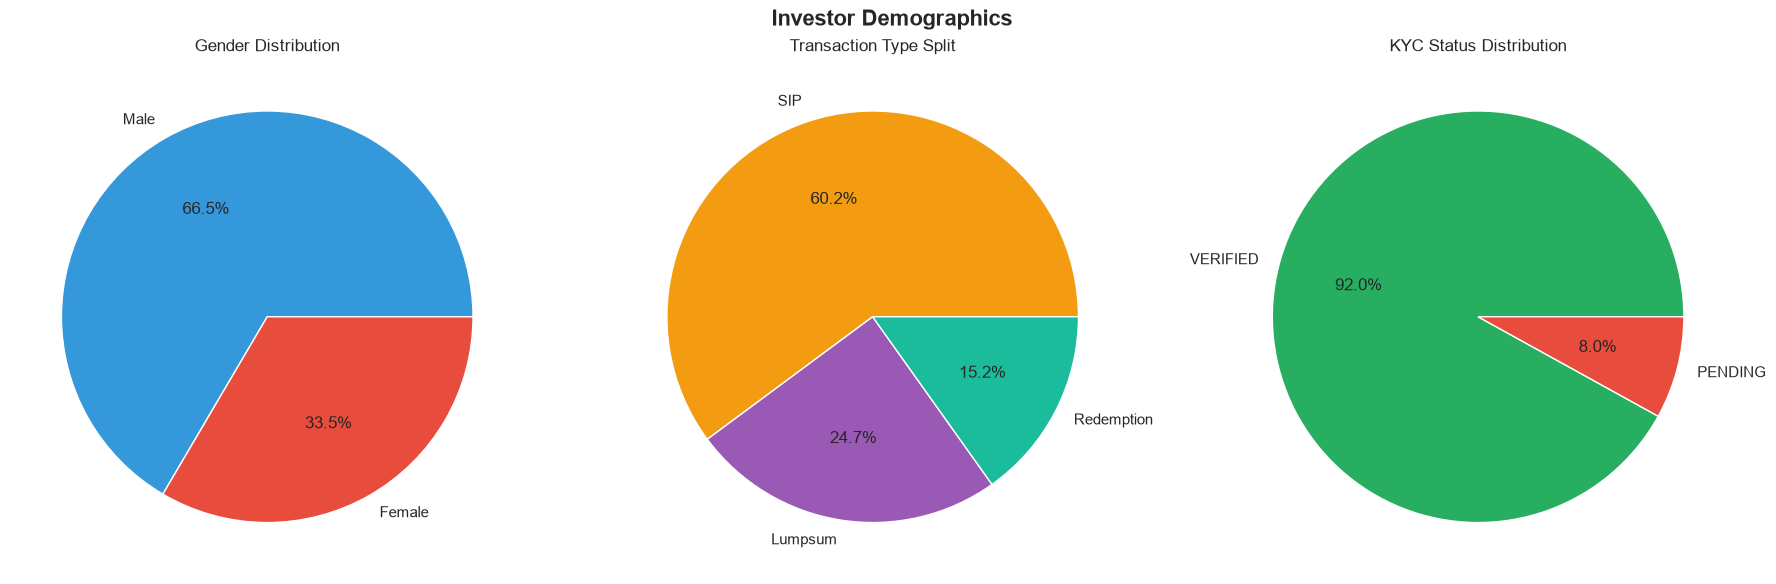

✅ Chart 5: Demographics done!


In [16]:
# Cell 9: Investor Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Gender Split Pie Chart
gender_counts = trans_df['gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Gender Distribution')

# 2. Transaction Type Pie
type_counts = trans_df['transaction_type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['#f39c12', '#9b59b6', '#1abc9c'])
axes[1].set_title('Transaction Type Split')

# 3. KYC Status
kyc_counts = trans_df['kyc_status'].value_counts()
axes[2].pie(kyc_counts.values, labels=kyc_counts.index,
            autopct='%1.1f%%', colors=['#27ae60', '#e74c3c'])
axes[2].set_title('KYC Status Distribution')

plt.suptitle('Investor Demographics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports\chart5_demographics.png', dpi=150)
plt.show()
print("✅ Chart 5: Demographics done!")

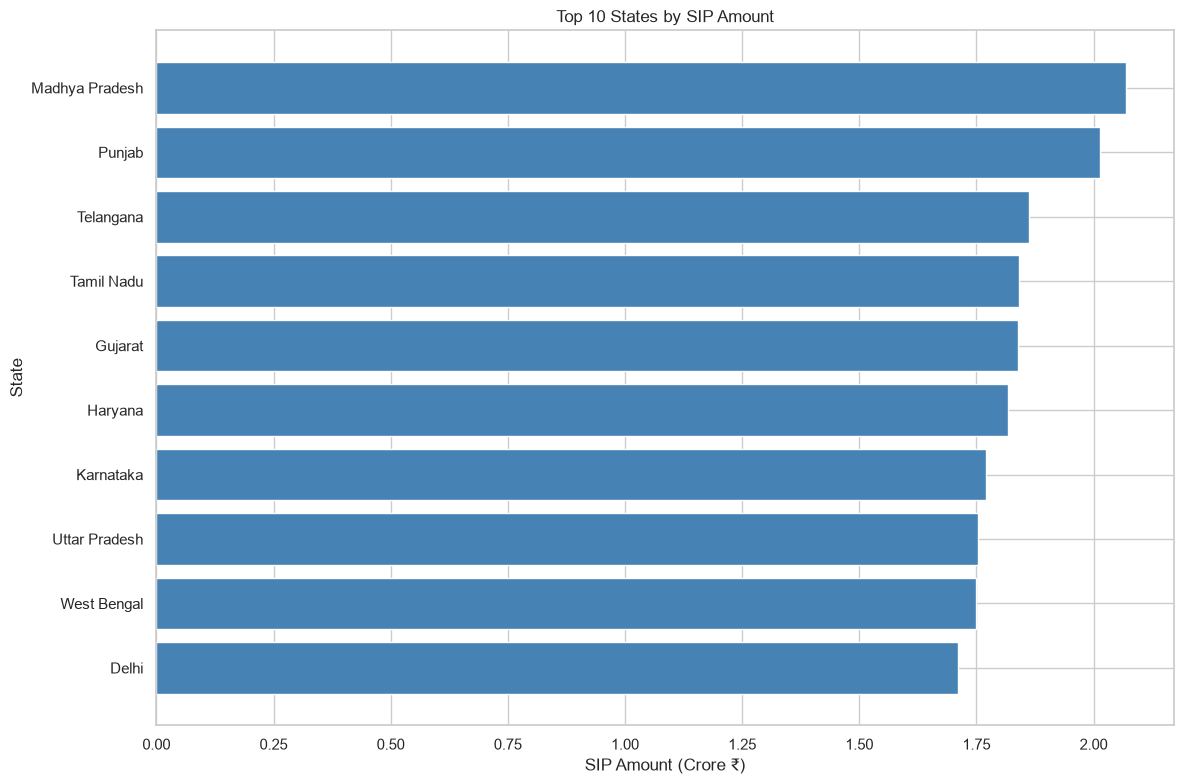

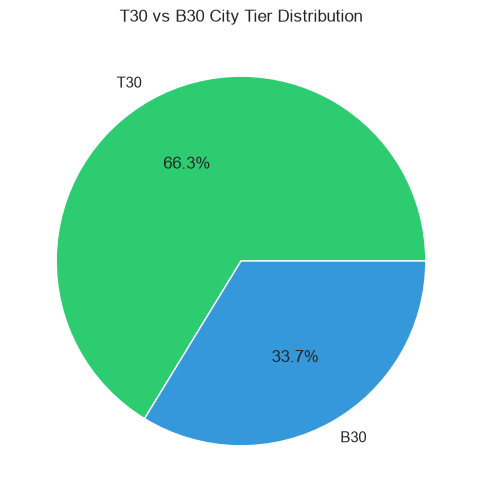

✅ Chart 6: Geographic done!


In [17]:
# Cell 10: Geographic Distribution
state_sip = trans_df[trans_df['transaction_type']=='SIP'].groupby('state')['amount_inr'].sum().reset_index()
state_sip = state_sip.sort_values('amount_inr', ascending=True).tail(10)

plt.figure(figsize=(12, 8))
plt.barh(state_sip['state'], state_sip['amount_inr']/1e7,
         color='steelblue')
plt.title('Top 10 States by SIP Amount')
plt.xlabel('SIP Amount (Crore ₹)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports\chart6_geographic.png', dpi=150)
plt.show()

# City Tier Pie
tier_counts = trans_df['city_tier'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(tier_counts.values, labels=tier_counts.index,
        autopct='%1.1f%%', colors=['#2ecc71','#3498db','#e74c3c'])
plt.title('T30 vs B30 City Tier Distribution')
plt.savefig(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports\chart6b_citytier.png', dpi=150)
plt.show()
print("✅ Chart 6: Geographic done!")

In [18]:
# Cell 11: Folio Count Growth
print(folio_df.columns.tolist())
print(folio_df.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


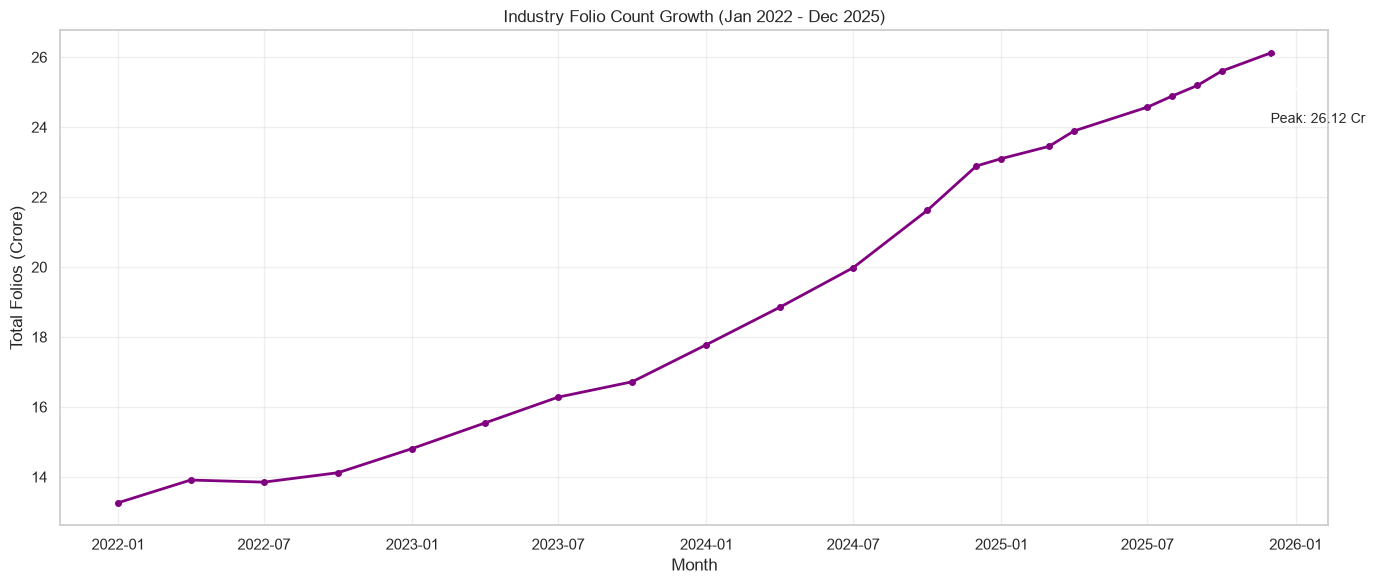

✅ Chart 7: Folio Count done!


In [19]:
# Cell 12: Folio Count Growth Line Chart
folio_df['month'] = pd.to_datetime(folio_df['month'])

plt.figure(figsize=(14, 6))
plt.plot(folio_df['month'], folio_df['total_folios_crore'],
         color='purple', linewidth=2, marker='o', markersize=4)
plt.title('Industry Folio Count Growth (Jan 2022 - Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.grid(True, alpha=0.3)

# Mark milestones
max_val = folio_df['total_folios_crore'].max()
max_month = folio_df.loc[folio_df['total_folios_crore'].idxmax(), 'month']
plt.annotate(f'Peak: {max_val:.2f} Cr',
             xy=(max_month, max_val),
             xytext=(max_month, max_val-2),
             arrowprops=dict(arrowstyle='->'),
             fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports\chart7_folio.png', dpi=150)
plt.show()
print("✅ Chart 7: Folio Count done!")

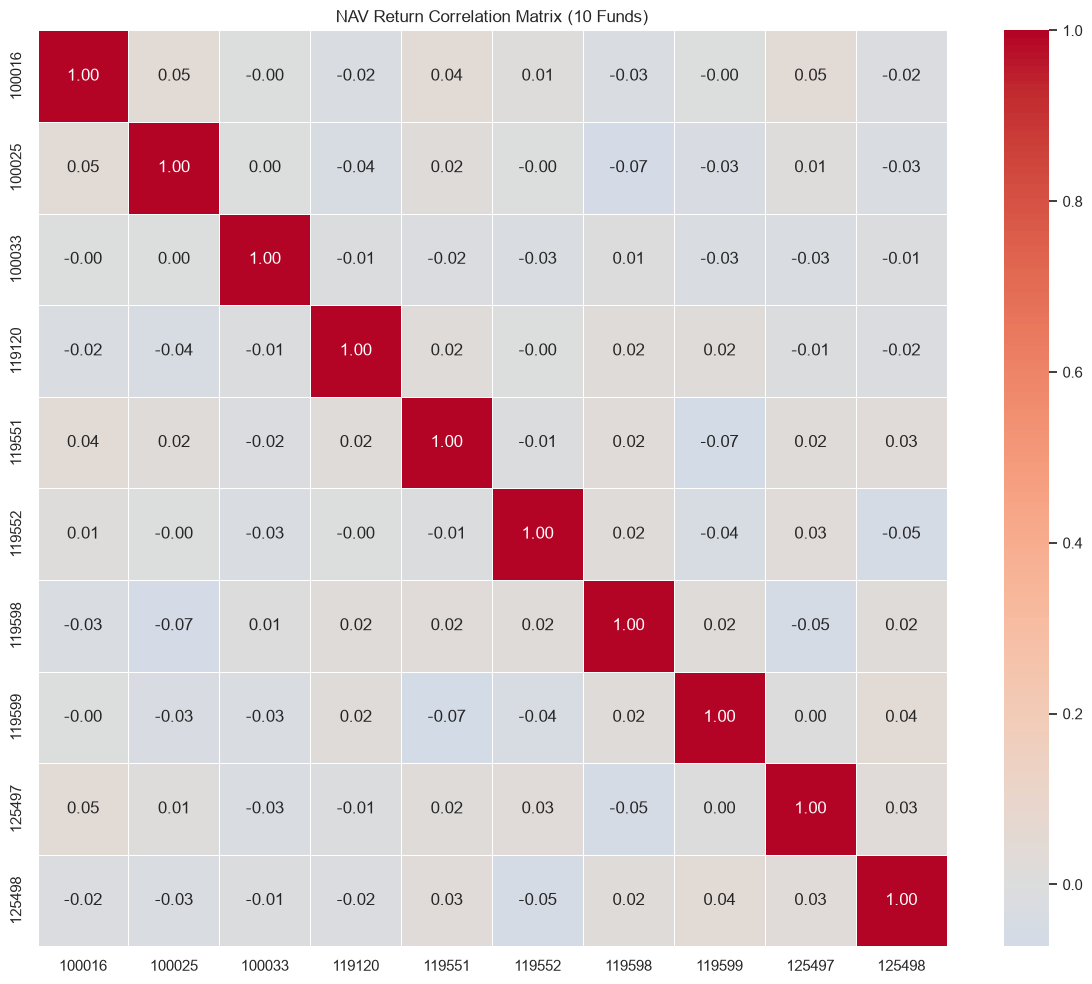

✅ Chart 8: Correlation Matrix done!


In [20]:
# Cell 13: NAV Return Correlation Matrix
# Pick 10 funds
top10_funds = fund_df['amfi_code'].head(10).tolist()
nav_top10 = nav_df[nav_df['amfi_code'].isin(top10_funds)].copy()

# Pivot: date x fund
nav_pivot = nav_top10.pivot_table(index='date', columns='amfi_code', values='nav')

# Daily returns
returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr = returns.corr()

# Get scheme names for labels
code_name = fund_df.set_index('amfi_code')['scheme_name'].to_dict()
corr.columns = [str(c) for c in corr.columns]
corr.index = [str(i) for i in corr.index]

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5)
plt.title('NAV Return Correlation Matrix (10 Funds)')
plt.tight_layout()
plt.savefig(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports\chart8_correlation.png', dpi=150)
plt.show()
print("✅ Chart 8: Correlation Matrix done!")

In [21]:
# Cell 14: Sector Allocation Donut Chart
print(portfolio_df.columns.tolist())
print(portfolio_df.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


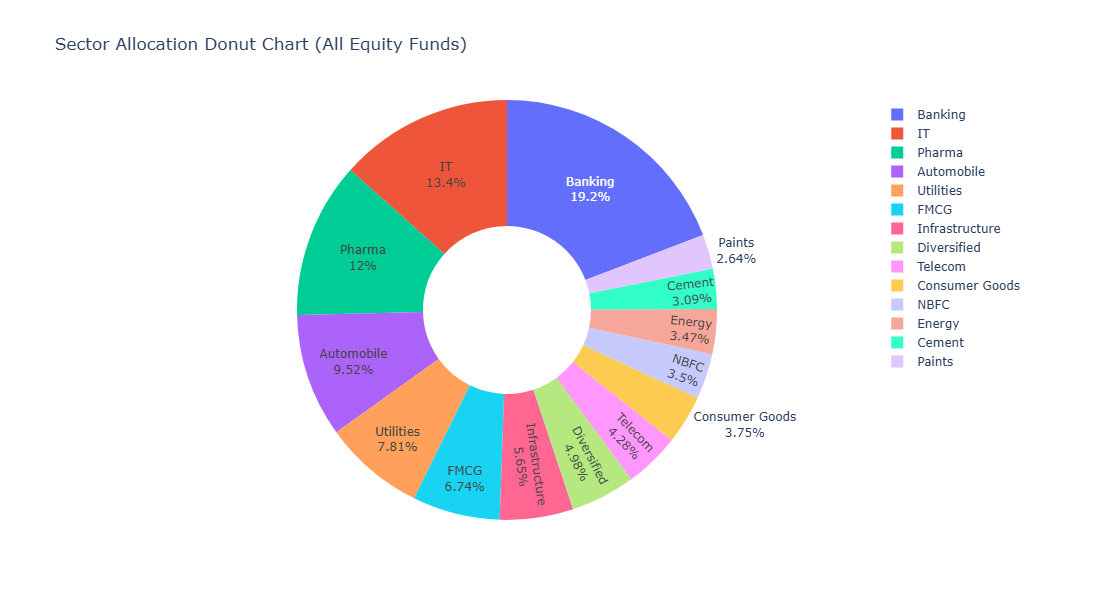

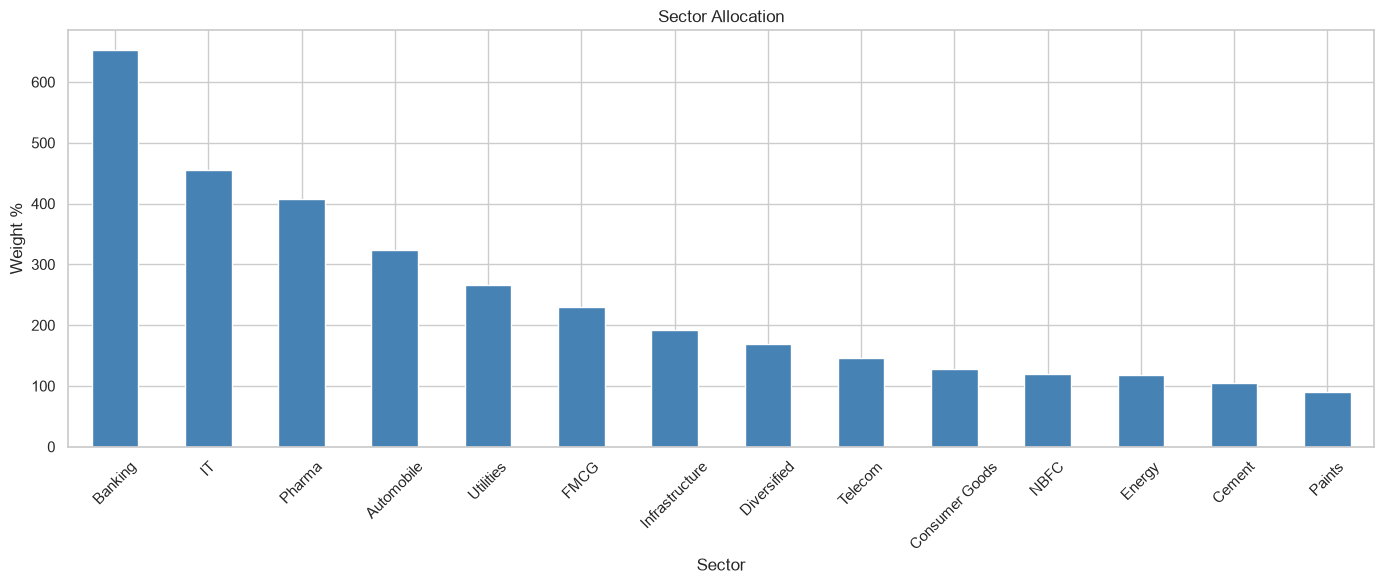

✅ Chart 9: Sector Allocation done!


In [22]:
# Cell 15: Sector Allocation Donut
sector_weights = portfolio_df.groupby('sector')['weight_pct'].sum().reset_index()
sector_weights = sector_weights.sort_values('weight_pct', ascending=False)

fig = go.Figure(data=[go.Pie(
    labels=sector_weights['sector'],
    values=sector_weights['weight_pct'],
    hole=0.4,
    textinfo='label+percent'
)])
fig.update_layout(
    title='Sector Allocation Donut Chart (All Equity Funds)',
    height=600
)
fig.show()

# Save as image
sector_weights.plot(kind='bar', x='sector', y='weight_pct',
                   figsize=(14,6), color='steelblue', legend=False)
plt.title('Sector Allocation')
plt.xlabel('Sector')
plt.ylabel('Weight %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\gayat\OneDrive\Documents\mutual_fund_analytics\reports\chart9_sector.png', dpi=150)
plt.show()
print("✅ Chart 9: Sector Allocation done!")

# 🔍 10 Key EDA Findings — Mutual Fund Analytics

## 1. SBI Mutual Fund — Market Leader
SBI dominates with ₹84,91,000 Cr AUM — highest among all fund houses.

## 2. SIP is King 👑
60.2% of all transactions are SIP — investors prefer systematic investment.

## 3. NAV Growth (2022-2026)
HDFC Top 100 NAV grew from ₹500 to ₹800 — 60% growth in 4 years.

## 4. KYC Compliance is High ✅
92% investors are KYC verified — strong regulatory compliance.

## 5. Liquid Funds Dominate Inflows
Category heatmap shows Liquid funds have highest net inflow consistently.

## 6. Male Investors Dominate
66.5% male vs 33.5% female — gender gap exists in mutual fund investing.

## 7. T30 Cities Lead
60.3% transactions from T30 cities — metros drive mutual fund growth.

## 8. SIP Inflows Growing Rapidly 📈
Monthly SIP inflows grew from ₹10,000 Cr to ₹20,000 Cr (2022-2025).

## 9. Banking & Utilities Top Sectors
HDFC Bank and Power Grid are top holdings across equity funds.

## 10. Folio Count Doubling
Industry folios grew from 13.26 Cr to 26.12 Cr — retail participation doubled!